### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**:
*   Your **student number**:



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [3]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [4]:
print(raw_data.columns)
#Download the list of countries
countries_text = requests.get(countries_list_url).text

#Convert the text into a list of countries
countries_list = countries_text.splitlines()

#Keeping only countries that are in the country list
population_data = raw_data[raw_data["entity"].isin(countries_list)]

#Keeping only years from 1901 to 2023
population_data = population_data[(population_data["year"] >= 1901) &(population_data["year"] <= 2023)]

#changing the dataframe format
population_df = population_data.pivot(
    index="entity",
    columns="year",
    values="population_historical"
)

#Remove all the countries with missing values
population_df = population_df.dropna()

#Display the  dataframe
population_df

Index(['entity', 'code', 'year', 'population_historical'], dtype='object')


year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,2733334.0,2765603.0,2796321.0,2827377.0,2858773.0,2890514.0,2922603.0,2955044.0,2985778.0,3014767.0,...,30254080.0,30573968.0,30765719.0,30565331.0,29807591.0,28938096.0,28444080.0,28237830.0,28213015.0,28300861.0
Vietnam,12199511.0,12734169.0,13412346.0,14126641.0,14878976.0,15671378.0,16505981.0,17385031.0,18088666.0,18608564.0,...,91679582.0,92823254.0,94000115.0,95176978.0,96237319.0,97173778.0,98079196.0,98935101.0,99680656.0,100352189.0
Yemen,2984894.0,3006808.0,3033193.0,3059809.0,3086657.0,3113742.0,3141063.0,3168624.0,3196638.0,3225110.0,...,30226311.0,31159378.0,32109023.0,33090923.0,34085181.0,35111416.0,36134867.0,37140234.0,38222878.0,39390800.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

In [5]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
def plot_countries(dataframe, countries, ylabel):
    #Find the total number of countries in the countries list. This number will be used to decide how many plots need to be created.
    number_of_countries = len(countries)

    #Creating a figure and a set of subplots using matplotlib. One subplot is created for each country in the countries list.The plots will be arranged vertically in one column.
    fig, axes = plt.subplots(number_of_countries,1,figsize=(10, 4 * number_of_countries))

    #Loop through every country in the countries list.
    for i in range(number_of_countries):

        #Get the country name at index i from the countries list.
        country = countries[i]

        #Plot the population data for the current country. dataframe.columns contains the years and is used for the x-axis and dataframe.loc[country] selects the population values for the current country and is used for the y-axis.
        axes[i].plot(
            dataframe.columns,
            dataframe.loc[country]
        )

        #Set the title of the current subplot to the country's name.
        axes[i].set_title(country)

        #Label the horizontal axis as Year.
        axes[i].set_xlabel("Year")

        #Set the y-axis label using the ylabel argument given to the function.
        axes[i].set_ylabel(ylabel)

        #Adding grid lines to the current plot to make the data easier to read.
        axes[i].grid()

    #adjust the spacing between the subplots.

    plt.tight_layout()

    #Display all of the completed plots.
    plt.show()

    #Create the StandardScaler
scaler = StandardScaler()

#Standardize the population data
standardized_data = scaler.fit_transform(population_df)

#Convert the result back into a dataframe
standardized_df = pd.DataFrame(
    standardized_data,
    index=population_df.index,
    columns=population_df.columns
)

standardized_df



year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,-0.100165,-0.100047,-0.099763,-0.099484,-0.099208,-0.098936,-0.098672,-0.098414,-0.096248,-0.092059,...,-0.034059,-0.029623,-0.026427,-0.022423,-0.017953,-0.013063,-0.007375,-0.003373,-0.001763,0.001713
Albania,-0.210133,-0.210609,-0.211095,-0.211588,-0.212088,-0.212596,-0.213114,-0.213642,-0.214023,-0.214260,...,-0.246648,-0.247677,-0.248635,-0.249513,-0.250503,-0.251641,-0.252834,-0.254159,-0.255592,-0.257056
Algeria,-0.099160,-0.098461,-0.097624,-0.096782,-0.095934,-0.095080,-0.094224,-0.093365,-0.092700,-0.092229,...,0.011552,0.013996,0.016545,0.019132,0.021633,0.024039,0.026348,0.028763,0.031174,0.033249
Andorra,-0.232726,-0.233281,-0.233835,-0.234396,-0.234965,-0.235540,-0.236126,-0.236721,-0.237152,-0.237421,...,-0.266777,-0.267602,-0.268379,-0.269074,-0.269870,-0.270801,-0.271785,-0.272866,-0.274068,-0.275342
Angola,-0.146728,-0.148310,-0.149959,-0.151601,-0.153239,-0.154871,-0.156500,-0.158127,-0.159538,-0.160733,...,-0.074116,-0.069620,-0.064978,-0.060195,-0.055368,-0.050451,-0.045471,-0.040285,-0.035004,-0.029793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,-0.156518,-0.156610,-0.156777,-0.156950,-0.157129,-0.157316,-0.157511,-0.157715,-0.157832,-0.157861,...,-0.052114,-0.052588,-0.053920,-0.057906,-0.065601,-0.073903,-0.079425,-0.082776,-0.084907,-0.086371
Vietnam,0.107849,0.120210,0.136253,0.153063,0.170677,0.189130,0.208459,0.228705,0.244040,0.254323,...,0.384787,0.386222,0.387904,0.389559,0.390787,0.391611,0.392784,0.394463,0.395622,0.396112
Yemen,-0.149492,-0.149912,-0.150238,-0.150573,-0.150915,-0.151265,-0.151625,-0.151996,-0.152221,-0.152301,...,-0.052311,-0.048461,-0.044534,-0.040415,-0.036213,-0.031787,-0.027272,-0.022681,-0.017604,-0.012108


In [6]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.0 MB/s eta 0:00:00


In [7]:
import Levenshtein

first_name = "Mansoor"

# Create an empty list to store each countr and its Levenshtein edit distance
country_distances = []

#Loop through every country in the population dataframe
for country in population_df.index:
    distance = Levenshtein.distance(
        first_name.lower(),country.lower())
    country_distances.append((country, distance))

#Sort the list using the edit distance.
country_distances.sort(key=lambda x: x[1])

#Display the 10 countries with the smallest distances
country_distances[:10]

[('Andorra', 4),
 ('Angola', 4),
 ('Monaco', 4),
 ('Myanmar', 4),
 ('Cameroon', 5),
 ('Canada', 5),
 ('Congo', 5),
 ('Ecuador', 5),
 ('Gabon', 5),
 ('Laos', 5)]

In [11]:
#Select the two countries with the smallest distance.Four countries have the same minimum distance (4).Since the list is already sorted by distance, the first two countries are selected.
closest_countries = [country_distances[0][0],country_distances[1][0]]
print(closest_countries)

selected_countries = closest_countries.copy()

#Required countries
required_countries = [
    "Japan",
    "Bosnia and Herzegovina",
    "Latvia",
    "United Arab Emirates"
]

#Add each required country if it is not already in the list
for country in required_countries:
    if country not in selected_countries:
        selected_countries.append(country)

# Display the final list
print(selected_countries)

['Andorra', 'Angola']
['Andorra', 'Angola', 'Japan', 'Bosnia and Herzegovina', 'Latvia', 'United Arab Emirates']


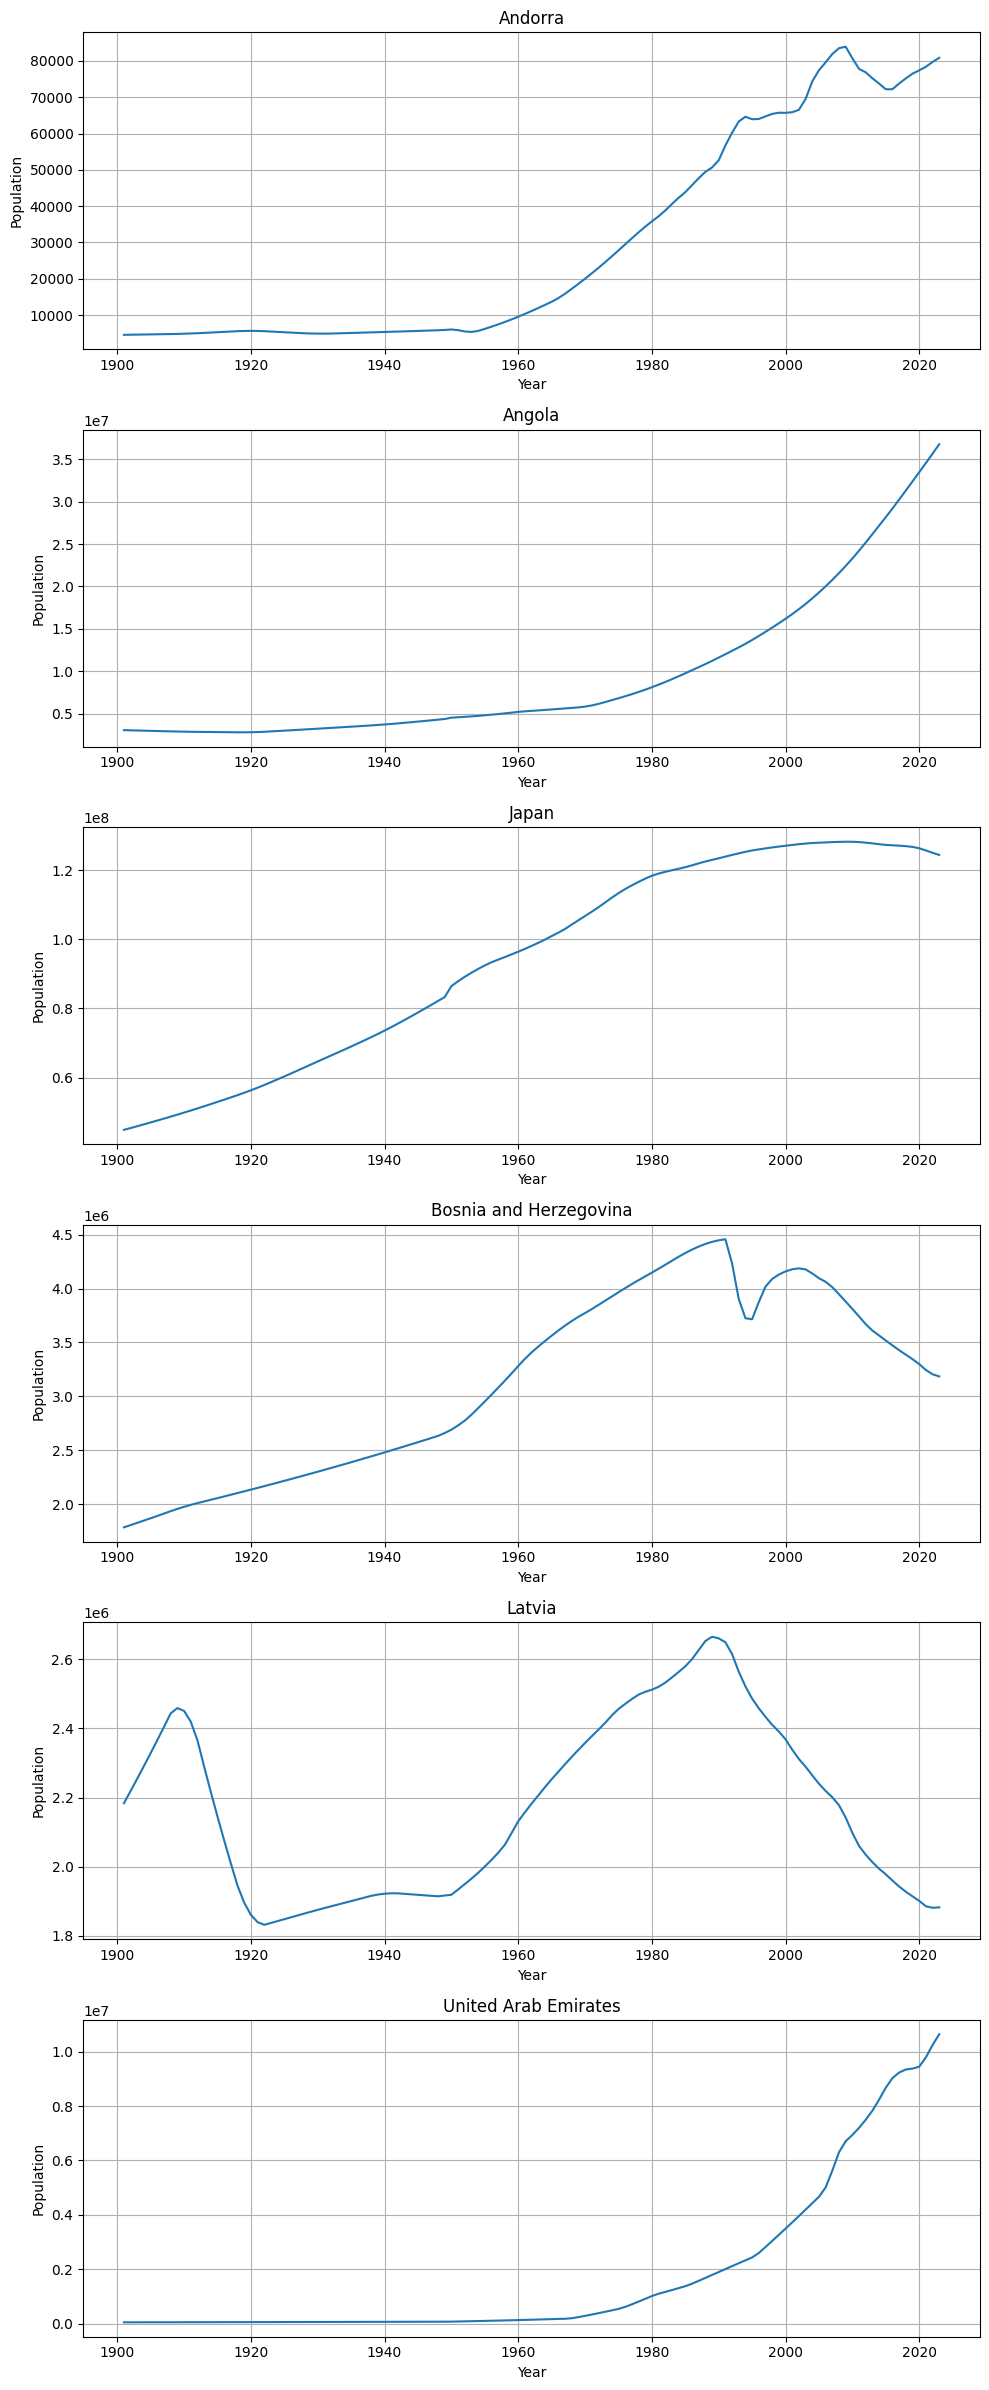

In [12]:
#PLot for the original data
plot_countries(
    population_df,
    selected_countries,
    "Population"
)

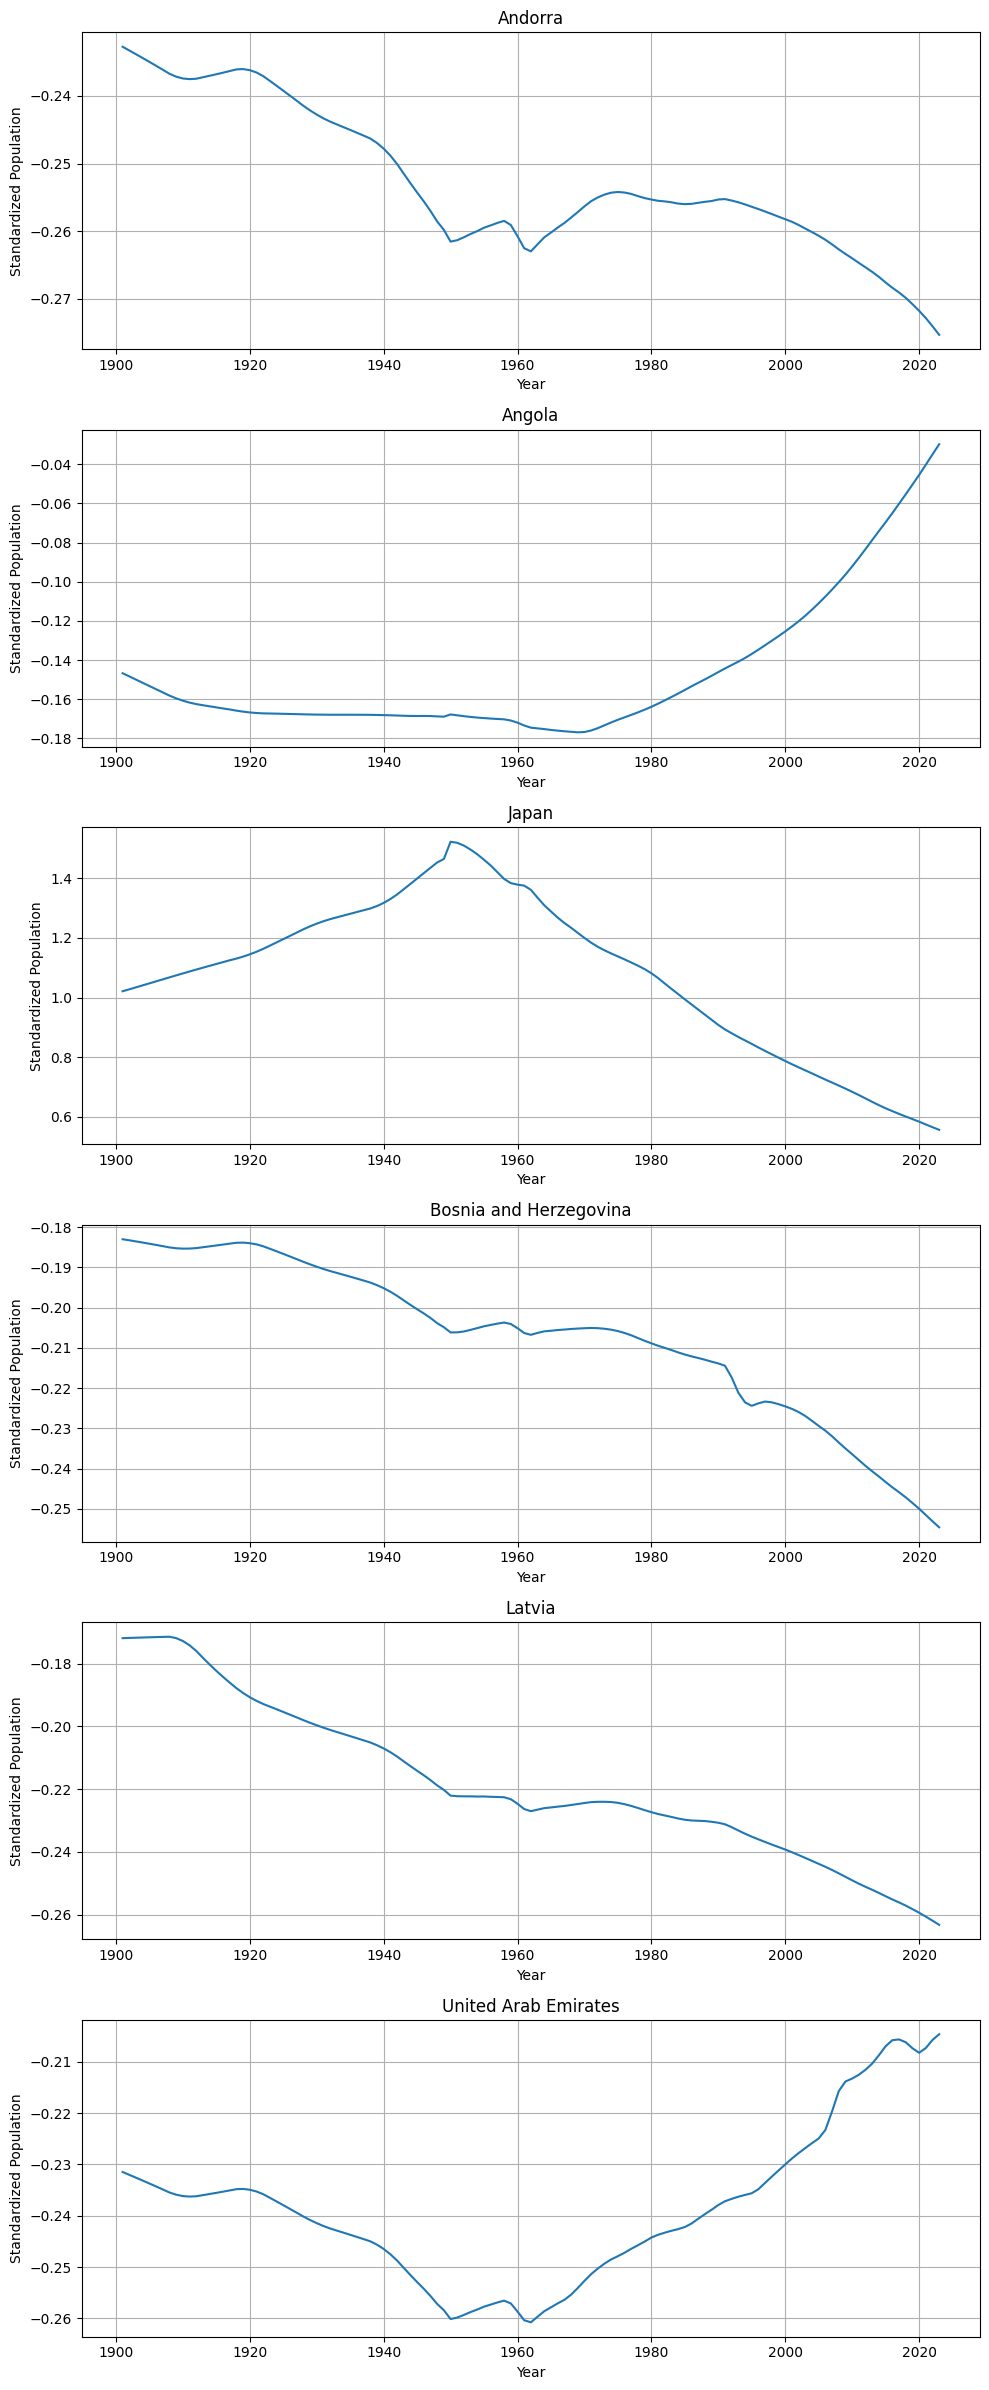

In [13]:
#Plot for the standardized data
plot_countries(
    standardized_df,
    selected_countries,
    "Standardized Population"
)

In [ ]:
"""
After standardizing the population data using the StandardScaler, each year has a mean of 0 and a standard deviation of 1. This means that the plots show how each country's population compares to the average population of all countries in a particular year.
If the standardized curve goes up, it means that the country's population is becoming larger relative to the average population of all countries. This indicates that the country is moving further above the average over time. If the standardized curve goes down, it means that the country's population is becoming smaller relative to the average population of all countries. This does not necessarily mean that the country's population is decreasing. The population may still be increasing, but it is growing more slowly than the average growth of other countries.
A positive standardized value means that the country's population is above the average population for that year. A negative standardized value means that the country's population is below the average population for that year. A value close to zero means that the country's population is close to the average population for that year.
"""